# Synthetic Manifold Data in Python

In [212]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 


### Manifold Data Generation

In [213]:
def _beta_lin(n, a=1.0, b=1.0, lo=0.0, hi=1.0, rng=None):
    rng = np.random.default_rng(rng)
    t = rng.beta(a, b, n)
    return lo + (hi - lo) * t

def add_ambient_noise(X, sigma=0.0, rng=None):
    if sigma <= 0: 
        return X
    rng = np.random.default_rng(rng)
    return X + rng.normal(0, sigma, X.shape)


def swiss_roll(n=2000, height=10.0, turns=3.0, hole=False, hole_center=(8.0, 5.0), 
               hole_radius=2.0, density=('beta',2,5), noise=0.0, rng=None):
    rng = np.random.default_rng(rng)
    if density == 'uniform':
        t = rng.uniform(0, 2*np.pi*turns, n)
    else:
        _, a, b = density
        t = _beta_lin(n, a, b, lo=0, hi=2*np.pi*turns, rng=rng)
    y = rng.uniform(0, height, n)
    x = t * np.cos(t)
    z = t * np.sin(t)
    X = np.vstack([x, y, z]).T
    if hole:
        mask = ( (X[:,0]-hole_center[0])**2 + (X[:,2]-hole_center[1])**2 ) > hole_radius**2
        X = X[mask]
    X_noise = add_ambient_noise(X, noise, rng)
    return X_noise, X, dict(name='swiss_roll', n=len(X), height=height, turns=turns, hole=hole)


def s_curve(n=2000, width=2.0, height=4.0, density=('beta',2,5), noise=0.0, rng=None):
    rng = np.random.default_rng(rng)
    if density == 'uniform':
        t = rng.uniform(0, 1, n)
    else:
        _, a, b = density
        t = _beta_lin(n, a, b, rng=rng)
    t = (t - 0.5) * np.pi * 1.5
    x = np.sin(t)
    z = np.sign(t)*(1 - np.cos(t))
    y = rng.uniform(0, height, n) - height/2
    X = np.vstack([width*x, y, width*z]).T
    X_noise = add_ambient_noise(X, noise, rng)
    return X_noise, X, dict(name='s_curve', n=n)

def torus(n=4000, R=3.0, r=1.0, noise=0.0, rng=None):
    rng = np.random.default_rng(rng)
    u = rng.uniform(0, 2*np.pi, n)
    v = rng.uniform(0, 2*np.pi, n)
    x = (R + r*np.cos(v))*np.cos(u)
    y = (R + r*np.cos(v))*np.sin(u)
    z = r*np.sin(v)
    X = np.vstack([x, y, z]).T
    X_noise = add_ambient_noise(X, noise, rng)
    return X_noise, X, dict(name='torus', n=n, R=R, r=r)

def mobius(n=4000, w=0.3, noise=0.0, rng=None):
    rng = np.random.default_rng(rng)
    u = rng.uniform(0, 2*np.pi, n)
    v = rng.uniform(-w, w, n)
    x = (1 + v*np.cos(u/2))*np.cos(u)
    y = (1 + v*np.cos(u/2))*np.sin(u)
    z = v*np.sin(u/2)
    X = np.vstack([x, y, z]).T
    X_noise = add_ambient_noise(X, noise, rng)
    return X_noise, X, dict(name='mobius', n=n, w=w)

def add_nuisance_dims(X, nuisance_dim=5, noise_scale=0.1, rng=None):
    rng = np.random.default_rng(rng)
    n_samples = X.shape[0]
    nuisance = rng.normal(0, noise_scale, size=(n_samples, nuisance_dim))
    return np.hstack([X, nuisance])


### Verifying Noise Estimator Properties

We have

$$
\hat{L}\big(\hat{\mathbf W}(\sigma^2),\sigma^2\big)
= \sum_{i=1}^N
  \frac{1}{\bm{1}^\top H_i^{-1}\bm{1}}
  - N\sigma^2 D,
\qquad H_i = C_i - \sigma^2 D\,I_{k_i}
$$
and
$$
G_i := \big[\,\bm{z}_{i}-\bm{z}_j\,\big]_{j\in\tilde{\mathcal{N}}_i}\in\mathbb R^{D\times k_i},
\qquad
C_i := G_i^\top G_i\in\mathbb R^{k_i\times k_i}.
$$

Proposition 3 and 4 in the appendix imply that this function should be convex in $\sigma^2$ over $0 < \sigma^2 < \min_i \lambda_{\min}(C_i)/D$. 

In [221]:
from scipy.spatial import cKDTree, KDTree

N = 5000 # number of samples
sigma = 0.1 # noise standard deviation
dim = 3 # ambient data dimension
Zw, Xw, meta = swiss_roll(n=N, height=10.0, turns=3.0, hole=True, hole_center=(8.0,5.0), hole_radius=2.0, noise=sigma, rng=0)#torus(n=N,noise=sigma, rng=0)
# Z, X = Zw, Xw


X = (Xw - Xw.mean(axis=0)) / Xw.std(axis=0)
Z = add_ambient_noise(X, sigma = sigma, rng=0)
# Z = add_nuisance_dims(Zw, nuisance_dim=dim-3, noise_scale=0.01, rng=0) # ambient data 
# X = add_nuisance_dims(Xw, nuisance_dim=dim-3, noise_scale=0.01, rng=0) # clean data
k = 3 # number of neighbors

def get_GC_matrices(Z, k, return_eigvals=True):
    tree = cKDTree(Z)
    dists, idx = tree.query(Z, k=k+1)      # first neighbour is itself
    nn = Z[idx[:,1:]]                      # (N, k, D)
    G = Z[:, None, :] - nn                 # (N, k, D) columns: z_i - z_j
    C = G @ np.transpose(G, (0, 2, 1))     # (N, k, k)
    eigvals = None
    if return_eigvals:
        eigvals = np.linalg.eigvalsh(C)   
    return G, C, eigvals

def LLE_loss(sigma2, c_matrices, Z):

    sigma2 = np.atleast_1d(sigma2).astype(float)  # (S,)
    N, D = Z.shape
    N_, k, k_ = c_matrices.shape
    assert N_ == N and k == k_
    
    # Build H for each sigma2: shape (S, N, k, k)
    I_k = np.eye(k)[None, None, :, :]                  
    H = c_matrices[None, :, :, :] - (sigma2[:, None, None, None] * D) * I_k
    Hinv = np.linalg.pinv(H)
    # Hinv = np.linalg.inv(H)

    denom = Hinv.sum(axis=(-1, -2))                      # (S, N)

    loss = (1.0 / denom).sum(axis=1) - sigma2 * D * N    # (S,)

    return loss


g_matrices, c_matrices, c_eigvals = get_GC_matrices(Z, k) 

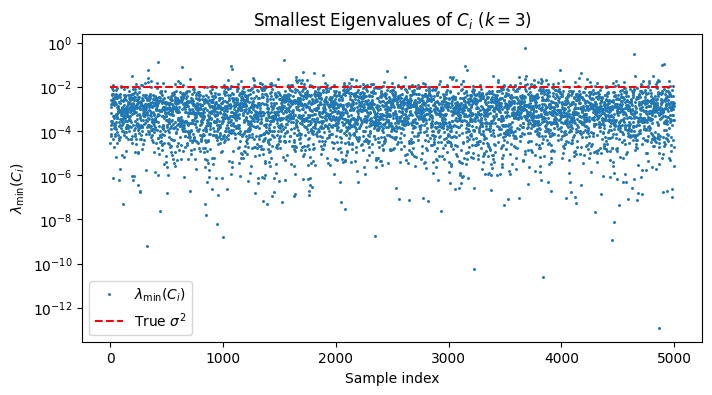

In [222]:
min_eigvals = np.min(c_eigvals, axis=1)
plt.figure(figsize=(8,4))
plt.plot(min_eigvals, 'o', label=r'$\lambda_{\min}(C_i)$', markersize=80 / N ** 0.5)
plt.xlabel('Sample index')
plt.ylabel(r'$\lambda_{\min}(C_i)$')
plt.hlines(y=sigma**2, xmin=0, xmax=N, color='r', linestyle='--', label=r'True $\sigma^2$')
plt.title(f'Smallest Eigenvalues of $C_i$ ($k = ${k})')
plt.yscale('log')
plt.legend()
plt.show()

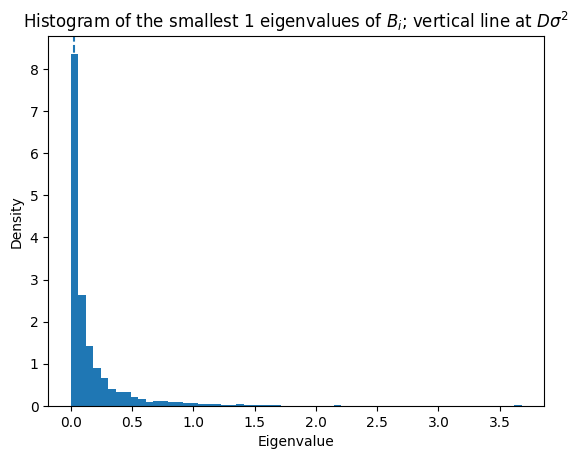

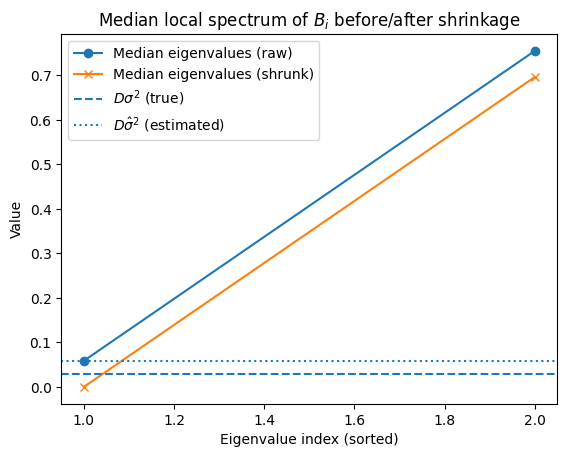

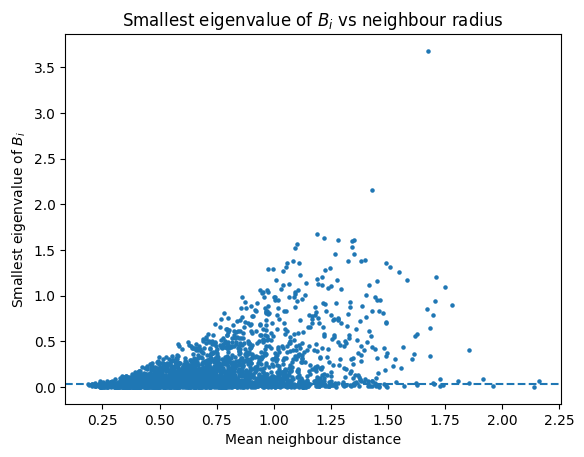

True sigma^2: 0.010000000000000002
Estimated sigma^2 from small eigs: 0.019566641333948007
k used: 3  => B size: 2  ; intrinsic d: 2  ; # noise-dominated eigenvalues per neighbourhood s = 1


In [225]:
# Corrected B = Q^T C Q contraction and full visualisation pipeline

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

def ones_constraint_basis(k: int):
    one = np.ones((k,))
    w0 = one / k
    A = np.eye(k); A[:, 0] = one / np.sqrt(k)
    Qfull, _ = np.linalg.qr(A)
    if np.dot(Qfull[:, 0], one / np.sqrt(k)) < 0:
        Qfull[:, 0] *= -1
    Q = Qfull[:, 1:]
    return w0, Q

def swiss_roll(n=2000, height=10.0, turns=2.5, hole=False, hole_center=(8.0,5.0), hole_radius=2.0, noise=0.0, rng=0):
    rng = np.random.default_rng(rng)
    t = rng.uniform(1.5*np.pi, 1.5*np.pi + 2*np.pi*turns, size=n)
    x = t * np.cos(t)
    y = height * rng.uniform(0, 1, size=n)
    z = t * np.sin(t)
    X = np.vstack([x, y, z]).T
    if hole:
        cx, cz = hole_center
        r = np.sqrt((x-cx)**2 + (z-cz)**2)
        mask = r > hole_radius
        X = X[mask]
    if noise > 0:
        X = X + rng.normal(0, noise, size=X.shape)
    return X

def add_ambient_noise(X, sigma=0.05, rng=0):
    rng = np.random.default_rng(rng)
    return X + rng.normal(0, sigma, size=X.shape)

def get_GC_matrices(Z, k):
    tree = cKDTree(Z)
    dists, idx = tree.query(Z, k=k+1)
    nn = Z[idx[:,1:]]
    G = Z[:, None, :] - nn
    C = np.einsum('nkd,nqd->nkq', G, G)  # (N,k,k)
    return idx[:,1:], G, C

def local_B_from_C(C):
    N, k, _ = C.shape
    _, Q = ones_constraint_basis(k)  # (k,k-1)
    CQ = np.einsum('nkp,pr->nkr', C, Q)          # (N,k,k-1)
    B  = np.einsum('pk,nkr->npr', Q.T, CQ)       # (N,k-1,k-1) == Q^T C Q
    return B, Q

def estimate_sigma2_from_small_eigs(B_eigs, D, d):
    N, r = B_eigs.shape
    s = max(r - d, 1)
    small = np.sort(B_eigs, axis=1)[:, :s]
    sigma2_hat = np.median(small) / D
    return sigma2_hat, s, small

def shrink_B(B, sigma2_hat, D, eps=1e-10):
    N, r, _ = B.shape
    B_shrunk = np.zeros_like(B)
    for i in range(N):
        w, V = np.linalg.eigh(B[i])
        w_sh = np.maximum(w - D*sigma2_hat, eps)
        B_shrunk[i] = V @ (w_sh[:, None] * V.T)
    return B_shrunk

# Data
N = 3000; D = 3; d_intrinsic = 2; sigma = 0.10
X_clean = swiss_roll(n=N, height=10.0, turns=3.0, hole=True, hole_center=(8.0,5.0), hole_radius=2.0, noise=0.0, rng=0)
Z = add_ambient_noise(X_clean, sigma=sigma, rng=1)

# Build locals
k_user = 10
k_demo = 3 #max(k_user, d_intrinsic + 3)  # ensure extra dims beyond d
nn_idx, G, C = get_GC_matrices(Z, k=k_demo)
B, Q = local_B_from_C(C)

# Spectra and sigma2 estimate
B_eigs = np.linalg.eigvalsh(B)
sigma2_hat, s, small = estimate_sigma2_from_small_eigs(B_eigs, D=D, d=d_intrinsic)

# Shrinkage
B_sh = shrink_B(B, sigma2_hat=sigma2_hat, D=D, eps=1e-12)
B_eigs_sh = np.linalg.eigvalsh(B_sh)

# Plots
plt.figure()
vals = small.ravel()
plt.hist(vals, bins=60, density=True)
plt.axvline(D * sigma**2, linestyle='--')
plt.title("Histogram of the smallest {} eigenvalues of $B_i$; vertical line at $D\\sigma^2$".format(s))
plt.xlabel("Eigenvalue"); plt.ylabel("Density")
plt.show()

med_before = np.median(B_eigs, axis=0)
med_after  = np.median(B_eigs_sh, axis=0)
plt.figure()
plt.plot(np.arange(1, B_eigs.shape[1]+1), med_before, marker='o', label='Median eigenvalues (raw)')
plt.plot(np.arange(1, B_eigs_sh.shape[1]+1), med_after, marker='x', label='Median eigenvalues (shrunk)')
plt.axhline(D * sigma**2, linestyle='--', label='$D\\sigma^2$ (true)')
plt.axhline(D * sigma2_hat, linestyle=':', label='$D\\hat\\sigma^2$ (estimated)')
plt.title("Median local spectrum of $B_i$ before/after shrinkage")
plt.xlabel("Eigenvalue index (sorted)"); plt.ylabel("Value"); plt.legend()
plt.show()

# radius vs smallest eig
tree = cKDTree(Z)
dists, _ = tree.query(Z, k=k_demo+1)
radius = dists[:, 1:].mean(axis=1)
min_eigs = np.sort(B_eigs, axis=1)[:, 0]
plt.figure()
plt.scatter(radius, min_eigs, s=5)
plt.axhline(D * sigma**2, linestyle='--')
plt.title("Smallest eigenvalue of $B_i$ vs neighbour radius")
plt.xlabel("Mean neighbour distance"); plt.ylabel("Smallest eigenvalue of $B_i$")
plt.show()

print("True sigma^2:", sigma**2)
print("Estimated sigma^2 from small eigs:", sigma2_hat)
print("k used:", k_demo, " => B size:", k_demo-1, " ; intrinsic d:", d_intrinsic, " ; # noise-dominated eigenvalues per neighbourhood s =", s)


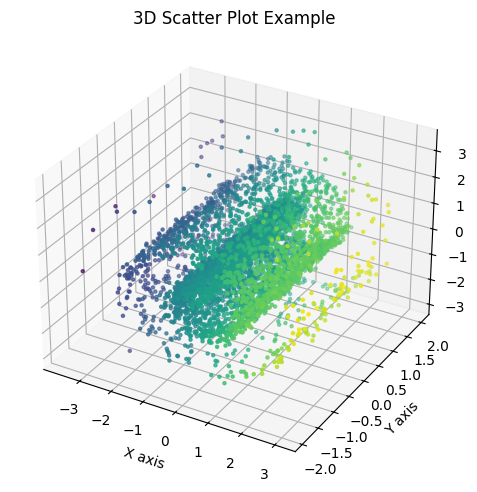

In [177]:
from mpl_toolkits.mplot3d import Axes3D  # (still needed for 3D projection)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(Z.T[0], Z.T[1], Z.T[2], c=Z.T[0], cmap='viridis', s=5)

# Axis labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('3D Scatter Plot Example')

plt.tight_layout()
plt.show()


In [199]:
import numpy as np
from scipy.spatial import cKDTree
import scipy.sparse as sp
import scipy.sparse.linalg as spla

def ones_constraint_basis(k: int):
    one = np.ones((k,))
    w0 = one / k
    A = np.eye(k); A[:, 0] = one / np.sqrt(k)
    Qfull, _ = np.linalg.qr(A)
    if np.dot(Qfull[:, 0], one / np.sqrt(k)) < 0:
        Qfull[:, 0] *= -1
    Q = Qfull[:, 1:]
    return w0, Q

def knn_indices(Z, k):
    tree = cKDTree(Z)
    _, idx = tree.query(Z, k=k+1)
    return idx[:, 1:]

def assemble_W_sparse(N, nn_idx, W_loc):
    rows = np.repeat(np.arange(N), nn_idx.shape[1])
    cols = nn_idx.ravel()
    data = W_loc.ravel()
    return sp.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()

import numpy as np
from scipy.spatial import cKDTree
import scipy.sparse as sp
import scipy.sparse.linalg as spla

def ones_constraint_basis(k: int):
    one = np.ones((k,))
    w0 = one / k
    A = np.eye(k); A[:, 0] = one / np.sqrt(k)
    Qfull, _ = np.linalg.qr(A)
    if np.dot(Qfull[:, 0], one / np.sqrt(k)) < 0:
        Qfull[:, 0] *= -1
    Q = Qfull[:, 1:]
    return w0, Q

def knn_indices(Z, k):
    tree = cKDTree(Z)
    _, idx = tree.query(Z, k=k+1)
    return idx[:, 1:]

def assemble_W_sparse(N, nn_idx, W_loc):
    rows = np.repeat(np.arange(N), nn_idx.shape[1])
    cols = nn_idx.ravel()
    data = W_loc.ravel()
    return sp.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()

def bayesian_lle(
    Z, k=12, em_steps=2, tau2=0.25,
    init_sigma2=None, a0=1e-6, b0=1e-6,
    sigma2_user=None,                    
    return_embedding=False, out_dim=2, rcond=1e-8
):
    """
    Bayesian EIV–LLE with latent clean design (short EM).
    If sigma2_user is given, sigma^2 is fixed to that value (no M-step).
    Otherwise sigma^2 is learned by a MAP update with an Inv-Gamma(a0,b0) prior.
    """
    N, D = Z.shape
    nn_idx = knn_indices(Z, k)
    w0, Q = ones_constraint_basis(k)
    r = k - 1

    # Build neighbourhood tensors
    Znbr = Z[nn_idx]                                  # (N,k,D)
    T = Z - np.einsum('nkd,k->nd', Znbr, w0)          # (N,D)
    Xobs = np.einsum('nkd,kr->ndr', Znbr, Q)          # (N,D,r)

    # Initialise sigma^2
    if sigma2_user is not None:
        sigma2 = float(sigma2_user)
        update_sigma2 = False
    else:
        if init_sigma2 is None:
            sigma2 = max(np.sum(T*T) / (D * N * (1.0 + 1.0/k)), 1e-6)
        else:
            sigma2 = float(init_sigma2)
        update_sigma2 = True

    # Warm-start theta by ridge on observed design
    S = np.einsum('ndr,ndq->nrq', Xobs, Xobs)         # (N,r,r)
    u = np.einsum('ndr,nd->nr', Xobs, T)              # (N,r)
    A0 = S + (sigma2 / tau2) * np.eye(r)[None,:,:]
    V0 = np.linalg.pinv(A0, rcond=rcond, hermitian=True)
    theta = np.einsum('nri,nr->ni', V0, u)            # (N,r)

    for _ in range(em_steps):
        # ---- E-step: row-wise Gaussian conditioning (vectorised) ----
        beta = np.sum(theta*theta, axis=1)                    # (N,)
        c = 1.0 / sigma2
        ct = 1.0 / (sigma2 * (1.0 + 1.0/k))
        denom = (c + ct * beta)                               # (N,)

        I_r = np.eye(r)[None,:,:]
        Sigma = (1.0/c) * I_r - (ct / (c * denom))[:,None,None] * np.einsum('ni,nj->nij', theta, theta)

        rhs = c * Xobs + ct * (theta[:,None,:] * T[:,:,None])
        mu  = np.einsum('ndr,nrq->ndq', rhs, Sigma)           # (N,D,r)

        EXtX   = D * Sigma + np.einsum('ndp,ndq->npq', mu, mu)    # (N,r,r)
        EXt    = np.einsum('ndp,nd->np', mu, T)                   # (N,r)
        trSig  = np.einsum('nii->n', Sigma)                       # (N,)
        Xm     = Xobs - mu
        EXdiff2 = D * trSig + np.einsum('ndr,ndr->n', Xm, Xm)     # (N,)
        t_minus = T - np.einsum('ndq,nq->nd', mu, theta)
        theta_S_theta = np.einsum('ni,nij,nj->n', theta, Sigma, theta)
        Etres2 = np.einsum('nd,nd->n', t_minus, t_minus) + D * theta_S_theta  # (N,)

        # ---- M-step: theta (ridge with expected stats) ----
        A = ct * EXtX + (1.0 / tau2) * I_r                        # (N,r,r)
        V = np.linalg.pinv(A, rcond=rcond, hermitian=True)
        b = ct * EXt                                              # (N,r)
        theta = np.einsum('nri,nr->ni', V, b)

        # ---- M-step: sigma^2 (skip if user fixed it) ----
        if update_sigma2:
            num = np.sum((1.0/(1.0+1.0/k)) * Etres2 + EXdiff2) + 2.0*b0
            den = D*N + D*(k-1)*N + 2.0*a0
            sigma2 = max(num / den, 1e-10)

    # Build weights
    W_loc = w0[None,:] + np.einsum('kr,nr->nk', Q, theta)
    W_loc = W_loc / W_loc.sum(axis=1, keepdims=True)

    if not return_embedding:
        return W_loc, nn_idx, sigma2, tau2

    W = assemble_W_sparse(N, nn_idx, W_loc)
    I = sp.eye(N, format='csr')
    Qmat = I - W
    M = (Qmat.T).dot(Qmat)
    vals, vecs = spla.eigsh(M, k=out_dim+1, sigma=0.0, which='LM')
    order = np.argsort(vals)
    Y = vecs[:, order[1:1+out_dim]]
    return W_loc, nn_idx, sigma2, tau2, Y



In [208]:
W_loc, nn_idx, sigma2_hat, tau2_hat, Y = bayesian_lle(
    Z, k=25, em_steps=100,  return_embedding=True, out_dim=2, rcond=1e-8, sigma2_user=sigma**2
)

print("sigma^2_hat =", sigma2_hat, "tau^2_hat =", tau2_hat)
# Y is the 2D embedding like standard LLE (use order[1:] vectors)


sigma^2_hat = 0.010000000000000002 tau^2_hat = 0.25


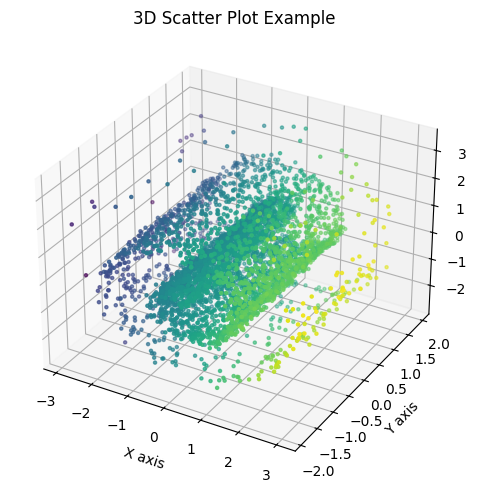

In [209]:

lambda_ = 1.0
k = 25
nn_idx = knn_indices(Z, k)

# local reconstruction: for each i, sum_j w_ij * z_j
X_denoised = lambda_ * np.einsum('nk,nkd->nd', W_loc, Z[nn_idx])


from mpl_toolkits.mplot3d import Axes3D  # (still needed for 3D projection)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(X_denoised.T[0], X_denoised.T[1], X_denoised.T[2], c=Z.T[0], cmap='viridis', s=5)

# Axis labels
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('3D Scatter Plot Example')

plt.tight_layout()
plt.show()


In [179]:
sigma**2

0.010000000000000002

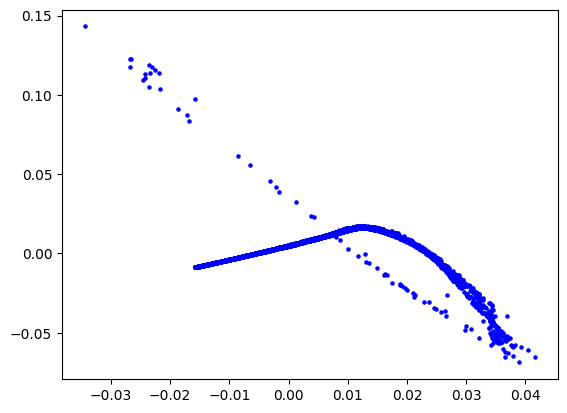

In [210]:
plt.scatter(Y[:,0], Y[:,1], c='blue', s=5)

In [148]:
# Your data:
# Z = ...   # (N, D)
# k = 20

W_loc, nn_idx, sigma2_hat, tau2_hat, Y = bayesian_lle(
    X, k=k, max_iter=10, tol=1e-6, return_embedding=True, out_dim=2
)

print("sigma^2_hat =", sigma2_hat, "tau^2_hat =", tau2_hat)
# Y is the 2D embedding like standard LLE (use order[1:] vectors)


sigma^2_hat = 1e-12 tau^2_hat = 0.2538773105386618


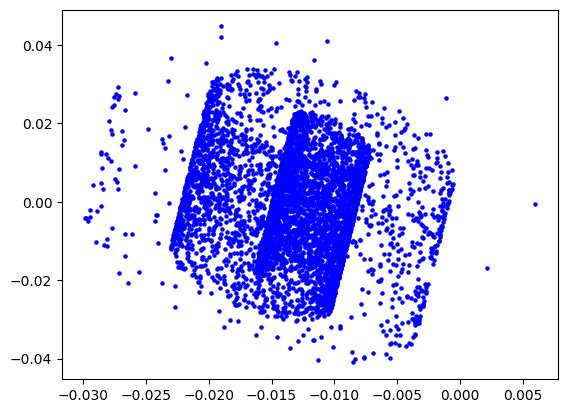

In [149]:
plt.scatter(Y[:,0], Y[:,1], c='blue', s=5)

In [141]:
import numpy as np
from scipy.spatial import cKDTree
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ------------------------------------------------------------
# Vectorised kNN
# ------------------------------------------------------------
def knn_indices(Z, k):
    tree = cKDTree(Z)
    _, idx = tree.query(Z, k=k+1)   # include self
    return idx[:, 1:]               # (N, k)

# ------------------------------------------------------------
# Vectorised LLE weights
# ------------------------------------------------------------
def lle_weights_vectorised(Z, nn_idx, reg_eps=1e-3, rcond=1e-12):
    """
    Vectorised LLE weights:
      - Builds all neighbourhood difference tensors in one go
      - Forms all (k x k) local Grams
      - Adds adaptive ridge reg_eps * tr(C_i)
      - Batched pseudoinverse, then normalise to sum to one
    """
    N, D = Z.shape
    k = nn_idx.shape[1]

    # Neighbour differences: X[i,j,:] = Z[nn_idx[i,j]] - Z[i]
    X = Z[nn_idx] - Z[:, None, :]                     # (N, k, D)

    # Local Grams: C[i] = X[i] @ X[i]^T
    C = X @ np.transpose(X, (0, 2, 1))                # (N, k, k)

    # Adaptive ridge per neighbourhood: reg = eps * trace(C_i)
    trC = np.trace(C, axis1=1, axis2=2)               # (N,)
    reg = reg_eps * trC
    I_k = np.eye(k)[None, :, :]                       # (1, k, k)
    C_reg = C + reg[:, None, None] * I_k              # (N, k, k)

    # Batched pseudoinverse (np.linalg.pinv supports stacks)
    # Use hermitian=True for speed since C_reg is symmetric
    C_pinv = np.linalg.pinv(C_reg, rcond=rcond, hermitian=True)  # (N, k, k)

    # Solve C^{-1} 1, normalise to sum-to-one
    one_k = np.ones((k, 1))
    v = C_pinv @ one_k                                 # (N, k, 1)
    v = v.squeeze(-1)                                  # (N, k)
    W_loc = v / v.sum(axis=1, keepdims=True)           # (N, k)

    return W_loc

# ------------------------------------------------------------
# Assemble sparse global W (vectorised)
# ------------------------------------------------------------
def assemble_W_sparse(N, nn_idx, W_loc):
    rows = np.repeat(np.arange(N), nn_idx.shape[1])
    cols = nn_idx.ravel()
    data = W_loc.ravel()
    W = sp.coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()
    return W

# ------------------------------------------------------------
# LLE embedding
# ------------------------------------------------------------
def lle_embed(W, out_dim=2):
    N = W.shape[0]
    I = sp.eye(N, format='csr')
    Q = I - W
    M = (Q.T).dot(Q)  # symmetric PSD

    # Smallest (out_dim + 1) eigenpairs near zero; skip the trivial eigenvector
    vals, vecs = spla.eigsh(M, k=out_dim+1, sigma=0.0, which='LM')
    order = np.argsort(vals)
    vals, vecs = vals[order], vecs[:, order]
    Y = vecs[:, 1:out_dim+1]
    return Y, vals

# ------------------------------------------------------------
# End-to-end vectorised vanilla LLE
# ------------------------------------------------------------
def vanilla_lle_vectorised(Z, k=12, out_dim=2, reg_eps=1e-3, rcond=1e-12):
    nn_idx = knn_indices(Z, k)                         # (N, k)
    W_loc = lle_weights_vectorised(Z, nn_idx, reg_eps=reg_eps, rcond=rcond)
    W = assemble_W_sparse(Z.shape[0], nn_idx, W_loc)
    Y, _ = lle_embed(W, out_dim=out_dim)
    return Y, W, W_loc, nn_idx


Y, W, W_loc, nn_idx = vanilla_lle_vectorised(Z, k=k, out_dim=2, reg_eps=1e-10)

# Optional: mean local reconstruction error (fully vectorised)
recon = np.einsum('nk,nkd->nd', W_loc, Z[nn_idx])     # (N, D)
recon_err = np.mean(np.sum((Z - recon)**2, axis=1))
print("Mean local reconstruction error:", recon_err)


Mean local reconstruction error: 2.865871384156077e-18


In [211]:
# 95% HDI for Beta(13, 208) — uses SciPy if available, otherwise falls back to mpmath.
import mpmath as mp

try:
    from scipy.stats import beta as sp_beta
    def ppf(q, a, b): return float(sp_beta.ppf(q, a, b))
except Exception:
    # mpmath-based inverse CDF
    def beta_cdf_mpmath(x, a, b):
        if x <= 0: return 0.0
        if x >= 1: return 1.0
        return float(mp.betainc(a, b, 0, x, regularized=True))
    def ppf(q, a, b):
        lo, hi = 0.0, 1.0
        for _ in range(100):
            mid = (lo + hi)/2
            if beta_cdf_mpmath(mid, a, b) < q:
                lo = mid
            else:
                hi = mid
        return (lo + hi)/2

def hdi_min_width_beta(a, b, cred_mass=0.95, coarse=2001, fine_steps=4001, fine_span=0.02):
    # Coarse sweep over starting quantiles q in [0, 1-cred_mass]
    qs = [i/(coarse-1)*(1-cred_mass) for i in range(coarse)]
    best = min(((ppf(q+cred_mass,a,b)-ppf(q,a,b), q) for q in qs), key=lambda t: t[0])
    q0 = best[1]
    # Refine around best q0
    qmin = max(0.0, q0 - fine_span/2); qmax = min(1.0-cred_mass, q0 + fine_span/2)
    qgrid = [qmin + i/(fine_steps-1)*(qmax-qmin) for i in range(fine_steps)]
    width, qstar = min(((ppf(q+cred_mass,a,b)-ppf(q,a,b), q) for q in qgrid), key=lambda t: t[0])
    return ppf(qstar, a, b), ppf(qstar+cred_mass, a, b)

a, b = 13, 208
lo, hi = hdi_min_width_beta(a, b, 0.95)
eti = (ppf(0.025, a, b), ppf(0.975, a, b))
print("Equal-tailed 95% CI:", eti)
print("HDI 95% (min-width):", (lo, hi))


Equal-tailed 95% CI: (0.0318352057473533, 0.09334089150444935)
HDI 95% (min-width): (0.029675056917715048, 0.09028996680333518)


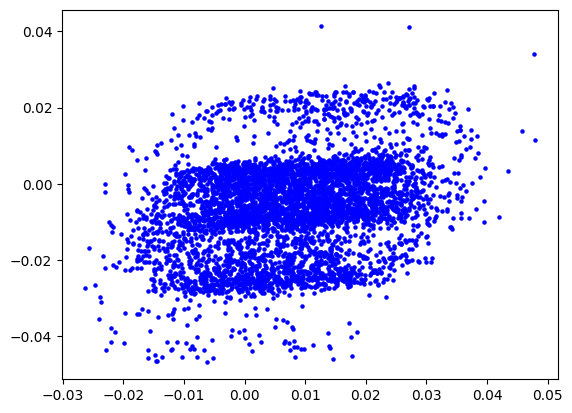

In [142]:
plt.scatter(Y[:,0], Y[:,1], c='blue', s=5)

In [183]:
Y, W, W_loc, nn_idx = vanilla_lle_vectorised(Z, k=24, out_dim=2, reg_eps=1e-9)

# Optional: mean local reconstruction error (fully vectorised)
recon = np.einsum('nk,nkd->nd', W_loc, Z[nn_idx])     # (N, D)
recon_err = np.mean(np.sum((X - recon)**2, axis=1))
print("Mean local reconstruction error:", recon_err)

Mean local reconstruction error: 0.02996170832226988


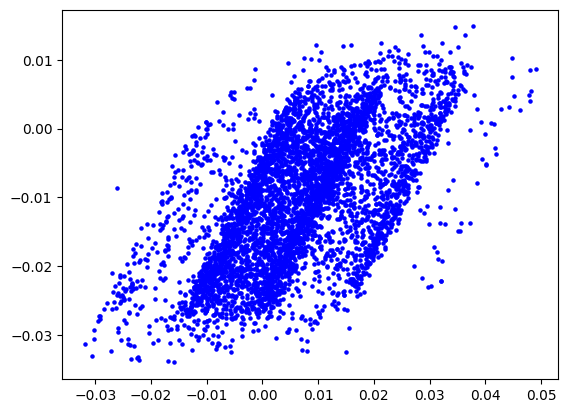

In [184]:
plt.scatter(Y[:,0], Y[:,1], c='blue', s=5)

### Plotting Eigenvalues of $C_i$ matrices

For each $i$, we compute the smallest eigenvalue of $C_i$, $\lambda_{\min}(C_i)$, and plot them.

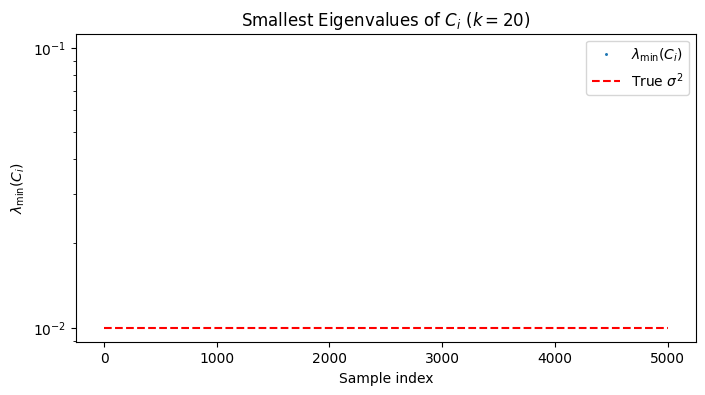

In [215]:
min_eigvals = np.min(c_eigvals, axis=1)
plt.figure(figsize=(8,4))
plt.plot(min_eigvals, 'o', label=r'$\lambda_{\min}(C_i)$', markersize=80 / N ** 0.5)
plt.xlabel('Sample index')
plt.ylabel(r'$\lambda_{\min}(C_i)$')
plt.hlines(y=sigma**2, xmin=0, xmax=N, color='r', linestyle='--', label=r'True $\sigma^2$')
plt.title(f'Smallest Eigenvalues of $C_i$ ($k = ${k})')
plt.yscale('log')
plt.legend()
plt.show()

### Plotting Loss over $\sigma^2$

In the following we will plot over all $\sigma^2$ values in the range $0 < \sigma^2 < \min_i \lambda_{\min}(C_i)/D$.


In [8]:
min_c_eig / dim

4.81252955493398e-05

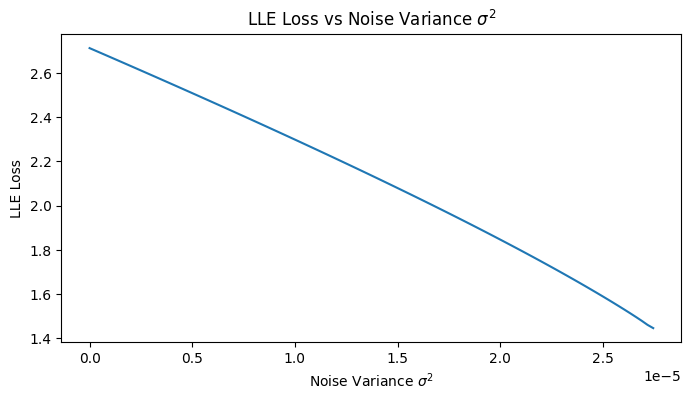

In [22]:
min_c_eig = np.min(c_eigvals) # overall minimum eigenvalue
sigma2_vals = np.linspace(0.0, min_c_eig / dim , 100) # sigma^2 values to evaluate

loss_vals = LLE_loss(sigma2_vals, c_matrices, Z) 

plt.figure(figsize=(8,4))
plt.title('LLE Loss vs Noise Variance $\sigma^2$')
plt.xlabel(r'Noise Variance $\sigma^2$')
plt.ylabel('LLE Loss')
plt.plot(sigma2_vals, loss_vals, '-')
plt.show()

Over a broader range of $\sigma^2$ values:

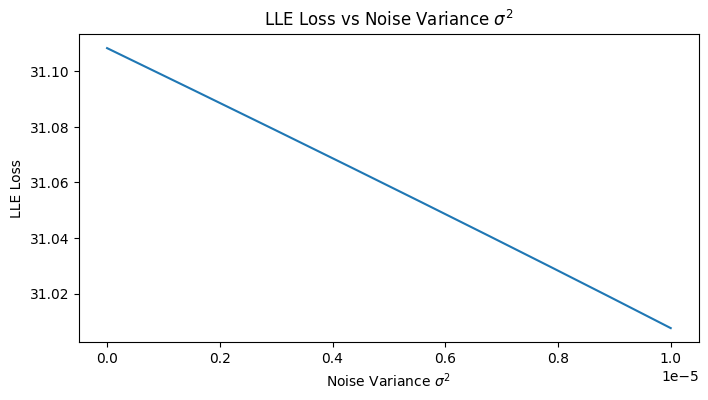

In [156]:
min_c_eig = np.min(c_eigvals) # overall minimum eigenvalue
sigma2_vals = np.linspace(0.0, 1e-5 , 801) # sigma^2 values to evaluate

loss_vals = LLE_loss(sigma2_vals, c_matrices, Z) 

plt.figure(figsize=(8,4))
plt.title('LLE Loss vs Noise Variance $\sigma^2$')
plt.xlabel(r'Noise Variance $\sigma^2$')
plt.ylabel('LLE Loss')
plt.plot(sigma2_vals, loss_vals, '-')
plt.show()

## Basis

In [9]:
import numpy as np
from scipy.spatial import cKDTree

# ----- data + neighbours (same as yours) --------------------------------------
N = 300
sigma = 0.1
dim = 50
Zw, meta = torus(n=N, noise=sigma, rng=0)
# Zw, meta = swiss_roll(...)

Z = add_nuisance_dims(Zw, nuisance_dim=dim-3, noise_scale=0.01, rng=0)
k = 8  # number of neighbours

def get_GC_matrices(Z, k, return_eigvals=True):
    tree = cKDTree(Z)
    dists, idx = tree.query(Z, k=k+1)      # first neighbour is itself
    nn = Z[idx[:, 1:]]                     # (N, k, D)
    G  = Z[:, None, :] - nn                # (N, k, D) columns: z_i - z_j
    C  = G @ np.transpose(G, (0, 2, 1))    # (N, k, k)
    eigvals = np.linalg.eigvalsh(C) if return_eigvals else None
    return G, C, eigvals

g_matrices, c_matrices, c_eigvals = get_GC_matrices(Z, k)

def ones_constraint_basis(k):
    """
    Return (u, Q) where u = 1/sqrt(k) * 1 (k-vector) and Q is k x (k-1),
    an orthonormal basis for {h : 1^T h = 0}. We construct it via QR with u as first column.
    """
    u = np.ones((k,)) / np.sqrt(k)
    A = np.eye(k)
    A[:, 0] = u  # first column = u
    Qfull, _ = np.linalg.qr(A)  # k x k orthonormal
    # Ensure the first column aligns with u (up to sign)
    if np.dot(Qfull[:, 0], u) < 0:
        Qfull[:, 0] *= -1
    Q_perp = Qfull[:, 1:]  # k x (k-1)
    return u, Q_perp

_u, Q_perp = ones_constraint_basis(k)
one = np.ones((k,))
w0 = one / k  # satisfies 1^T w0 = 1

def reduced_min_value(H, mode="pinv", tol=1e-10):
    """
    Solve min_{1^T w = 1} w^T H w without ridge.
    - mode='pinv': minimum-norm solution on PSD subspace using Moore–Penrose.
    - mode='psd_trunc': hard PSD positive-part projection before pseudoinverse (on reduced matrix).
    Returns: (min_value, w_opt, admissible_flag)
    admissible_flag=False if reduced matrix has a negative eigenvalue (< -tol).
    """
    # Reduce to the subspace {h : 1^T h = 0}
    H_red = Q_perp.T @ H @ Q_perp         # (k-1) x (k-1)
    b_red = Q_perp.T @ (H @ w0)           # (k-1,)

    # Eigen-decompose reduced matrix to test curvature on feasible directions
    evals, evecs = np.linalg.eigh(H_red)
    if np.any(evals < -tol):
        # Negative curvature in feasible directions -> unbounded below, inadmissible
        return np.nan, None, False

    if mode == "psd_trunc":
        # Positive-part spectral projection then pseudoinverse
        pos = evals > tol
        if not np.any(pos):
            # Entire reduced curvature is ~0: any feasible w has same value
            # Choose y*=0 (so w*=w0). Min value = w0^T H w0.
            w_star = w0.copy()
            return float(w_star @ H @ w_star), w_star, True
        inv_evals = np.zeros_like(evals)
        inv_evals[pos] = 1.0 / evals[pos]
        H_red_dag = (evecs @ np.diag(inv_evals) @ evecs.T)
        y_star = -H_red_dag @ b_red
    else:
        # mode == 'pinv' : Moore–Penrose on (PSD, possibly singular) H_red
        H_red_dag = np.linalg.pinv(H_red, rcond=1e-12)
        y_star = - H_red_dag @ b_red

    w_star = w0 + Q_perp @ y_star
    min_val = float(w_star @ H @ w_star)
    return min_val, w_star, True

# ----- loss across sigma2 values with admissibility accounting -----------------
def LLE_loss_pinv(sigma2_grid, c_matrices, D, mode="pinv", tol=1e-10):
    """
    Compute profiled loss over sigma2 values using constraint-subspace pseudoinverse.
    For each sigma2 and each i, form H_i = C_i - sigma2*D*I and:
      - if feasible curvature is PSD: take the minimal value w_i^T H_i w_i;
      - if negative curvature appears: mark term as inadmissible.
    Returns:
      losses: shape (S,)
      admissible_counts: shape (S,) number of neighbourhoods with PSD curvature
    """
    sigma2_grid = np.atleast_1d(sigma2_grid).astype(float)
    N, k, k_ = c_matrices.shape
    assert k == k_

    I = np.eye(k)
    losses = np.zeros_like(sigma2_grid)
    admissible_counts = np.zeros_like(sigma2_grid, dtype=int)

    for s, sig2 in enumerate(sigma2_grid):
        total = 0.0
        count_ok = 0
        for i in range(N):
            H_i = c_matrices[i] - (sig2 * D) * I
            min_val, _, ok = reduced_min_value(H_i, mode=mode, tol=tol)
            if ok:
                total += min_val
                count_ok += 1
            else:
                # Inadmissible: skip this neighbourhood (equivalently, +inf contribution)
                # You can also choose to set total=np.inf and break to reflect true ill-posedness.
                pass
        # Profiled loss: sum_i min w_i^T H_i w_i  - N*D*sigma^2
        # If you skipped inadmissible terms, you might prefer scaling by N or reporting count_ok.
        losses[s] = total - (N * D * sig2)
        admissible_counts[s] = count_ok

    return losses, admissible_counts

# Example usage:
# sigma2_vals = np.linspace(0.0, 0.2, 81)
# losses_pinv, counts = LLE_loss_pinv(sigma2_vals, c_matrices, D=Z.shape[1], mode="pinv", tol=1e-10)
# losses_psd, counts_psd = LLE_loss_pinv(sigma2_vals, c_matrices, D=Z.shape[1], mode="psd_trunc", tol=1e-10)


In [11]:
loss_vals

(array([1.99011783, 1.98105959, 1.97199226, 1.96291572, 1.95382984,
        1.94473448, 1.9356295 , 1.92651476, 1.91739011, 1.90825541,
        1.8991105 , 1.88995522, 1.88078942, 1.87161294, 1.86242559,
        1.85322721, 1.84401762, 1.83479664, 1.82556408, 1.81631975,
        1.80706345, 1.79779498, 1.78851412, 1.77922066, 1.76991439,
        1.76059507, 1.75126248, 1.74191636, 1.73255647, 1.72318256,
        1.71379436, 1.7043916 , 1.694974  , 1.68554128, 1.67609312,
        1.66662924, 1.6571493 , 1.64765298, 1.63813994, 1.62860983,
        1.61906228, 1.60949693, 1.59991337, 1.59031122, 1.58069004,
        1.57104941, 1.56138887, 1.55170796, 1.5420062 , 1.53228307,
        1.52253806, 1.51277062, 1.50298018, 1.49316615, 1.48332791,
        1.47346482, 1.4635762 , 1.45366135, 1.44371953, 1.43374997,
        1.42375187, 1.41372438, 1.40366661, 1.39357762, 1.38345643,
        1.373302  , 1.36311325, 1.35288902, 1.34262808, 1.33232915,
        1.32199086, 1.31161174, 1.30119026, 1.29

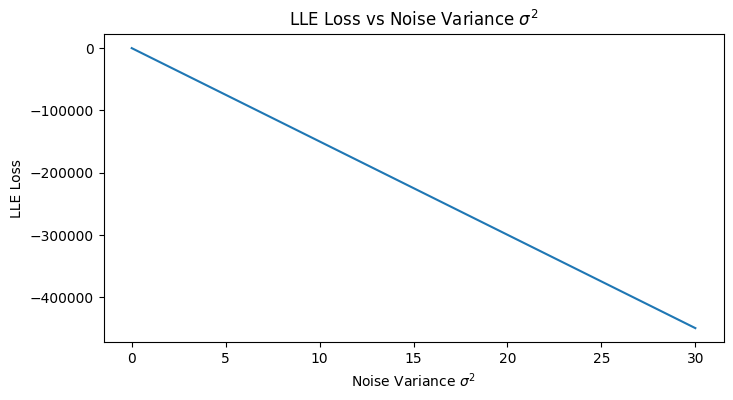

In [17]:
min_c_eig = np.min(c_eigvals) # overall minimum eigenvalue
sigma2_vals = np.linspace(0.0, 30 , 100) # sigma^2 values to evaluate

loss_vals, _ = LLE_loss_pinv(sigma2_vals, c_matrices, Z.shape[1]) 

plt.figure(figsize=(8,4))
plt.title('LLE Loss vs Noise Variance $\sigma^2$')
plt.xlabel(r'Noise Variance $\sigma^2$')
plt.ylabel('LLE Loss')
plt.plot(sigma2_vals, loss_vals, '-')
plt.show()